# Detección de Correo No Deseado (SPAM vs HAM)

**Materia:** Análisis de Lenguaje Natural  
**Carrera:** Ciencia de Datos e Inteligencia Artificial (CDIA)  
**Plantel:** CONALEP Tepic 169  

## Introducción

La detección de spam es una aplicación importante del **Procesamiento de Lenguaje Natural (NLP)** que consiste en identificar automáticamente si un mensaje es **correo no deseado (SPAM)** o **correo legítimo (HAM)**.

Este tipo de sistemas se utilizan ampliamente en:

- Servicios de correo electrónico
- Sistemas de mensajería
- Redes sociales
- Plataformas de comunicación empresarial

El objetivo principal es **proteger a los usuarios de contenido fraudulento, publicidad no deseada o intentos de phishing**.

En esta actividad se desarrollará un modelo de **clasificación de texto** utilizando técnicas de procesamiento de lenguaje natural y el algoritmo **Naive Bayes**, uno de los métodos más utilizados para detección de spam.

El proceso seguirá los siguientes pasos:

1. Limpieza y preprocesamiento de texto
2. Tokenización y eliminación de stopwords
3. Vectorización mediante TF-IDF
4. Entrenamiento de un modelo Naive Bayes
5. Evaluación del modelo
6. Predicción de nuevos mensajes en tiempo real
7. Guardado del modelo para uso futuro

In [59]:
# Librerías necesarias

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 1. Cargar Dataset de Mensajes

Para entrenar el modelo necesitamos un conjunto de mensajes etiquetados como:

- **SPAM** → correo no deseado
- **HAM** → correo normal

En este ejemplo utilizaremos un pequeño dataset de demostración con mensajes comunes.

In [60]:
data = {
    "mensaje": [

        # SPAM (20)
        "Felicidades ganaste un iPhone gratis haz clic aquí",
        "Gana dinero rápido desde casa regístrate ahora",
        "Oferta limitada compra ahora con 70 por ciento de descuento",
        "Has sido seleccionado para ganar un premio exclusivo",
        "Reclama tu premio de 1000 pesos ahora mismo",
        "Promoción especial solo hoy compra ahora",
        "Obtén un préstamo inmediato sin revisión de crédito",
        "Haz clic aquí para recibir tu regalo gratis",
        "Te regalamos un cupón de descuento exclusivo",
        "Ganaste un viaje gratis regístrate aquí",
        "Aprovecha esta oferta única antes de que termine",
        "Has ganado dinero reclama tu premio",
        "Compra ahora y recibe un segundo producto gratis",
        "Última oportunidad para obtener tu recompensa",
        "Tu cuenta fue seleccionada para recibir un bono",
        "Participa ahora para ganar premios increíbles",
        "Promoción exclusiva solo para ti",
        "Gana tarjetas de regalo completando esta encuesta",
        "Recibe dinero gratis solo registrándote",
        "Felicidades eres el ganador de nuestro sorteo",

        # HAM (20)
        "Hola cómo estás nos vemos mañana en la escuela",
        "Recuerda que tenemos reunión a las cinco",
        "Te mando el archivo que me pediste",
        "Nos vemos para estudiar en la biblioteca",
        "Avísame cuando llegues a casa",
        "Mañana tenemos examen de matemáticas",
        "Puedes ayudarme con la tarea de programación",
        "Te llamo más tarde para ponernos de acuerdo",
        "Ya envié el correo con el reporte",
        "Nos vemos en la cafetería después de clases",
        "No olvides traer los documentos mañana",
        "La reunión fue movida para el viernes",
        "Estoy trabajando en el proyecto del equipo",
        "Gracias por tu ayuda con la tarea",
        "Te paso el link de la clase grabada",
        "Voy en camino llego en diez minutos",
        "Confirmo nuestra reunión para mañana",
        "Ya terminé el ejercicio que pidió el profesor",
        "Podemos revisar el proyecto hoy en la tarde",
        "Nos vemos en clase mañana"
    ],

    "label": [

        # 20 spam
        "spam","spam","spam","spam","spam",
        "spam","spam","spam","spam","spam",
        "spam","spam","spam","spam","spam",
        "spam","spam","spam","spam","spam",

        # 20 ham
        "ham","ham","ham","ham","ham",
        "ham","ham","ham","ham","ham",
        "ham","ham","ham","ham","ham",
        "ham","ham","ham","ham","ham"
    ]
}

df = pd.DataFrame(data)

df.head()

,mensaje,label
0,Felicidades ganaste un iPhone gratis haz clic ...,spam
1,Gana dinero rápido desde casa regístrate ahora,spam
2,Oferta limitada compra ahora con 70 por ciento...,spam
3,Has sido seleccionado para ganar un premio exc...,spam
4,Reclama tu premio de 1000 pesos ahora mismo,spam


# 2. Limpieza y Preprocesamiento de Texto

Antes de analizar los mensajes es necesario **limpiar el texto** eliminando elementos que no aportan valor semántico.

Se aplicarán los siguientes pasos:

- Convertir el texto a **minúsculas**
- Eliminar **URLs**
- Eliminar **menciones (@usuario)**
- Eliminar **caracteres especiales**
- Eliminar **números**
- Eliminar **espacios múltiples**

Esto permite que el modelo trabaje únicamente con palabras relevantes.

In [61]:
def limpiar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r"http\S+|www\S+", "", texto)

    texto = re.sub(r"@\w+", "", texto)

    texto = re.sub(r"[^a-zA-Z\s]", "", texto)

    texto = re.sub(r"\d+", "", texto)

    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

In [62]:
df["mensaje_limpio"] = df["mensaje"].apply(limpiar_texto)

df[["mensaje", "mensaje_limpio"]].head()

,mensaje,mensaje_limpio
0,Felicidades ganaste un iPhone gratis haz clic ...,felicidades ganaste un iphone gratis haz clic aqu
1,Gana dinero rápido desde casa regístrate ahora,gana dinero rpido desde casa regstrate ahora
2,Oferta limitada compra ahora con 70 por ciento...,oferta limitada compra ahora con por ciento de...
3,Has sido seleccionado para ganar un premio exc...,has sido seleccionado para ganar un premio exc...
4,Reclama tu premio de 1000 pesos ahora mismo,reclama tu premio de pesos ahora mismo


# 3. Tokenización y Eliminación de Stopwords

La **tokenización** consiste en dividir el texto en palabras individuales llamadas **tokens**.

Posteriormente se eliminan las **stopwords**, que son palabras muy comunes que no aportan significado importante al análisis, como:

- el
- es
- y
- de
- en

Esto ayuda a reducir ruido en los datos y mejorar el rendimiento del modelo.

In [63]:
stop_words = set(stopwords.words("spanish"))

def procesar_tokens(texto):

    tokens = word_tokenize(texto)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [64]:
df["mensaje_procesado"] = df["mensaje_limpio"].apply(procesar_tokens)

df[["mensaje_limpio", "mensaje_procesado"]].head()

,mensaje_limpio,mensaje_procesado
0,felicidades ganaste un iphone gratis haz clic aqu,felicidades ganaste iphone gratis haz clic aqu
1,gana dinero rpido desde casa regstrate ahora,gana dinero rpido casa regstrate ahora
2,oferta limitada compra ahora con por ciento de...,oferta limitada compra ahora ciento descuento
3,has sido seleccionado para ganar un premio exc...,sido seleccionado ganar premio exclusivo
4,reclama tu premio de pesos ahora mismo,reclama premio pesos ahora mismo


In [65]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["mensaje_procesado"])

y = df["label"]

# 5. División de Datos de Entrenamiento y Prueba

Para evaluar correctamente el modelo se divide el dataset en:

- **Datos de entrenamiento (80%)**
- **Datos de prueba (20%)**

El modelo aprende con los datos de entrenamiento y luego se evalúa con los datos de prueba.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Entrenamiento del Modelo Naive Bayes

El algoritmo **Multinomial Naive Bayes** es uno de los más utilizados para clasificación de texto.

Esto se debe a que:

- Es rápido
- Funciona bien con datos de texto
- Maneja correctamente grandes cantidades de palabras

El modelo se entrena utilizando los vectores TF-IDF generados anteriormente.

In [67]:
modelo = MultinomialNB()

modelo.fit(X_train, y_train)

MultinomialNB()

In [68]:
predicciones = modelo.predict(X_test)

accuracy = accuracy_score(y_test, predicciones)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 1.0


# 7. Evaluación del Modelo

Para analizar el desempeño del modelo utilizamos una **matriz de confusión**.

La matriz muestra:

- **Verdaderos Positivos (TP)** → SPAM correctamente identificado
- **Verdaderos Negativos (TN)** → HAM correctamente identificado
- **Falsos Positivos (FP)** → HAM clasificado como SPAM
- **Falsos Negativos (FN)** → SPAM clasificado como HAM

Una buena matriz de confusión tendrá valores altos en la diagonal principal.

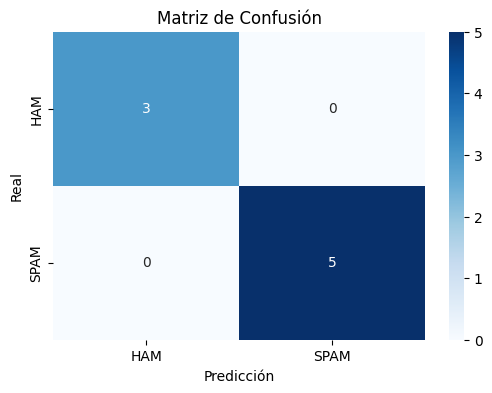

In [69]:
cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["HAM","SPAM"],
    yticklabels=["HAM","SPAM"]
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

# 8. Predicción de Mensajes en Tiempo Real

Se crea una función que permita ingresar un nuevo mensaje y que el modelo determine si es:

- **SPAM**
- **HAM**

También se mostrará el **nivel de confianza** de la predicción.

In [70]:
def predecir_mensaje(mensaje):

    mensaje = limpiar_texto(mensaje)

    mensaje = procesar_tokens(mensaje)

    vector = vectorizer.transform([mensaje])

    pred = modelo.predict(vector)[0]

    prob = modelo.predict_proba(vector).max()

    print("Mensaje:", mensaje)
    print("Clasificación:", pred.upper())
    print("Confianza:", round(prob,2))

In [71]:
predecir_mensaje(mensaje="¡Felicitaciones! ¡Ganaste un iPhone gratis!")

Mensaje: felicitaciones ganaste iphone gratis
Clasificación: SPAM
Confianza: 0.7


# 9. Guardar el Modelo

Para poder reutilizar el modelo en el futuro se puede guardar en un archivo utilizando **joblib**.

In [72]:
joblib.dump(modelo, "modelo_spam.pkl")

joblib.dump(vectorizer, "vectorizer.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente


# Conclusión

En esta actividad se desarrolló un sistema básico de **detección de correo no deseado** utilizando técnicas de **Procesamiento de Lenguaje Natural (NLP)**.

Se aplicaron diferentes etapas del procesamiento de texto, incluyendo:

- Limpieza de datos
- Tokenización
- Eliminación de stopwords
- Vectorización con TF-IDF

Posteriormente se entrenó un modelo de **Multinomial Naive Bayes**, el cual es especialmente efectivo para clasificación de texto debido a su simplicidad y eficiencia para manejar grandes cantidades de palabras.

El modelo fue evaluado mediante **accuracy y matriz de confusión**, permitiendo observar su desempeño en la clasificación de mensajes.

Finalmente, se implementó una función de **predicción en tiempo real**, capaz de analizar nuevos mensajes y determinar si corresponden a SPAM o HAM junto con su nivel de confianza.

Como mejoras futuras se podrían implementar:

- Uso de datasets más grandes
- Técnicas de **stemming o lemmatization**
- Modelos más avanzados como **Random Forest o redes neuronales**
- Uso de modelos de lenguaje modernos como **BERT**

Esto permitiría construir sistemas de filtrado de spam más precisos y robustos para aplicaciones reales.